In [118]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [119]:
survey_df = pd.read_csv("CSCI_Spring_2025_survey.csv")
survey_df


,Timestamp,What is your name?,What are your pronouns?,What state/country were you born in?,How many siblings do you have?,How much experience do you have programming?,What class are you in?,Are you working while in school?,How many pets and of which kind do you have?,What is your favorite type of food?,Where do you live?,Do you take the metro?,What is your major?,How old are you?,What is your favorite TV show?,What is your favorite video game?,What is your favorite book?,Why are you taking this class?,Whats your favorite bash command?
0,2024/09/05 5:10:09 PM CST,Alejandro (Alex) Gonzalez,He/Him,Mexico,1,1-2 years,Freshman,No,"1, Dog",Japanese,Off campus,No,Computer Science,18,Friends,Persona Series,Anything about mythology,My major,cd and ls
1,2024/09/05 5:33:51 PM CST,Tanmay,He/Him,Missouri,1,0-3 months,Freshman,No,0,Mexican,On campus,No,CS/Business,18,Suits,Super Smash bros,Percy Jackson,To get a deeper understanding and basics of cs,ls
2,2024/09/05 5:34:21 PM CST,Akshay,She/Her,"Frankfurt, Germany",1,0-3 months,Freshman,No,no pets!,Italian,On campus,No,Data Science,18,How I Met Your Mother,Mario Kart,Harry Potter,To learn programming for my major!,git commit
3,2024/09/05 5:35:03 PM CST,Anthony,He/Him,Wisconsin,1,0-3 months,Senior,Yes,I have two dogs and they are both at home,Italian,Off campus,No,Business Economics,21,Breaking Bad,Call of Duty,NaN,Programming has always been an interest of mine,ls
4,2024/09/05 5:35:56 PM CST,Nuri,He/Him,"st. louis, mo",2,1-2 years,Freshman,No,0,American,On campus,No,computer science,18,Hunter x Hunter,valorant,berserk,interested in having a career in data,ls
5,2024/09/05 5:35:57 PM CST,Molly,She/Her,Missouri,1,0-3 months,Freshman,No,0,Japanese,On campus,No,Computer Science,18,The Office,until dawn,I don't read books,to become a software engineer,print
6,2024/09/05 5:36:02 PM CST,Chris,He/Him,India,1,0-3 months,Freshman,No,none,Indian,On campus,No,cs/ finance,18,all of us are dead,minecraft,harry potter,its for my major,i dont know what that is
7,2024/09/05 5:36:13 PM CST,Steven,He/Him,St. Louis MO,1,6 months - 1 year,Freshman,Yes,NaN,Mexican,Off campus,No,Computer Science,18,X-Men 97,Devil Survivor 2 Overclocked,Series of Unfortunate Events - Reptile Room,To learn the basics of Coding since I only rea...,ls
8,2024/09/05 5:36:14 PM CST,Vekas,multiple: he/him and they/them,"Missouri, USA",2,0-3 months,Freshman,Yes,1 dog and 1 cat,Chinese,On campus,Yes,Computer Science; considering an additional ma...,18,It's Always Sunny In Philadelphia,Pikmin,Percy Jackson,It's required for my major + I know nothing ab...,cd
9,2024/09/05 5:36:24 PM CST,Mauricio,He/Him,Georgia (the country not the state),4,0-3 months,Freshman,Yes,"2 cats, one dog",Mexican,Off campus,No,Data Science,19,GOT,Minecraft,1984,Major Requirement,cd


In [120]:
survey_df["Birthplace_raw"] = (
    survey_df["What state/country were you born in?"]
    .astype(str)
    .str.lower()
    .str.strip()
)

def clean_birthplace(place):
    place = place.lower()


    if "missouri" in place or "st. louis" in place:
        return "Missouri, USA"
    elif "new jersey" in place:
        return "New Jersey, USA"
    elif "wisconsin" in place:
        return "Wisconsin, USA"
    elif "oklahoma" in place:
        return "Oklahoma, USA"
    elif "kansas" in place:
        return "Kansas, USA"
    elif "texas" in place:
        return "Texas, USA"
    elif "mexico" in place:
        return "Mexico"
    elif "india" in place:
        return "India"
    elif "germany" in place:
        return "Germany"
    elif "vietnam" in place:
        return "Vietnam"
    elif "china" in place:
        return "China"
    elif "cameroon" in place:
        return "Cameroon"
    elif "guatemala" in place:
        return "Guatemala"
    elif "south korea" in place or "seoul" in place:
        return "South Korea"
    elif "Georgia (the country not the state)" in place:
        return "Georgia country"
    else:
        return "Other"
survey_df["Birthplace_clean"] = survey_df["Birthplace_raw"].apply(clean_birthplace)
survey_df[["What state/country were you born in?", "Birthplace_clean"]].head(10)



,What state/country were you born in?,Birthplace_clean
0,Mexico,Mexico
1,Missouri,"Missouri, USA"
2,"Frankfurt, Germany",Germany
3,Wisconsin,"Wisconsin, USA"
4,"st. louis, mo","Missouri, USA"
5,Missouri,"Missouri, USA"
6,India,India
7,St. Louis MO,"Missouri, USA"
8,"Missouri, USA","Missouri, USA"
9,Georgia (the country not the state),Other


In [137]:


# 2. Standardize pets

def clean_pets(pet):
    pet = str(pet).lower().strip()

    if pet in ["0", "none", "no pets", "n/a"]:
        return "0 Pets"

    number = ""
    for char in pet:
        if char.isdigit():
            number += char
        else:
            break

    if number == "":
        number = "Unknown"

    has_dog = "dog" in pet
    has_cat = "cat" in pet

    if has_dog and has_cat:
        return f"{number} Pets (Dog and Cat)"
    elif has_dog:
        return f"{number} Dog(s)"
    elif has_cat:
        return f"{number} Cat(s)"
    else:
        return f"{number} Other Pets"

survey_df["Pets_clean"] = (
    survey_df["How many pets and of which kind do you have?"]
    .apply(clean_pets)
)


# 3. Standardize favorite food

def clean_food(food):
    food = str(food).lower()

    if "japanese" in food or "korean" in food or "chinese" in food:
        return "Asian"
    elif "italian" in food:
        return "Italian"
    elif "mexican" in food:
        return "Mexican"
    elif "american" in food:
        return "American"
    else:
        return "Other"

survey_df["Food_clean"] = (
    survey_df["What is your favorite type of food?"]
    .apply(clean_food)
)


# 4. Standardize majors

survey_df["What is your major?"] = (
    survey_df["What is your major?"]
    .astype(str)
    .str.lower()
    .str.replace("/", " and ")
)

def clean_major(major):
    major = str(major).lower()

    if "computer" in major or "cs" in major or "comp sci" in major:
        return "Computer Science"
    elif "data" in major:
        return "Data Science"
    elif "finance" in major:
        return "Finance"
    elif "economics" in major:
        return "Economics"
    elif "biology" in major:
        return "Biology"
    else:
        return "Other"

survey_df["Major_clean"] = (
    survey_df["What is your major?"]
    .apply(clean_major)
)

# 5. Standardize ages (grouped)

survey_df["How old are you?"] = pd.to_numeric(
    survey_df["How old are you?"])

def age_group(age):
    if age < 18:
        return "Under 18"
    elif age <= 19:
        return "18–19"
    else:
        return "20+"

survey_df["Age_group"] = (
    survey_df["How old are you?"]
    .apply(age_group)
)
survey_df = survey_df.rename(
    columns={"What is your name?": "Name"}
)

clean_df = survey_df[
    [   "Name",
        "Birthplace_clean",
        "Pets_clean",
        "Food_clean",
        "Major_clean",
        "Age_group"
    ]
]

print(clean_df.head())




                        Name Birthplace_clean          Pets_clean Food_clean  \
0  Alejandro (Alex) Gonzalez           Mexico            1 Dog(s)      Asian   
1                     Tanmay    Missouri, USA              0 Pets    Mexican   
2                     Akshay          Germany  Unknown Other Pets    Italian   
3                    Anthony   Wisconsin, USA      Unknown Dog(s)    Italian   
4                       Nuri    Missouri, USA              0 Pets   American   

        Major_clean Age_group  
0  Computer Science     18–19  
1  Computer Science     18–19  
2      Data Science     18–19  
3  Computer Science       20+  
4  Computer Science     18–19  


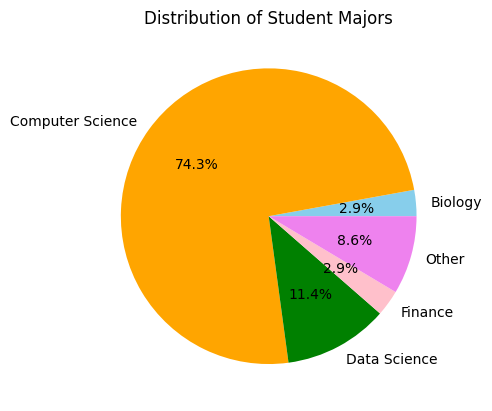

In [122]:
# The pie chart illustrates the proportion of students in each major, showing that Computer Science is the most common major among students.
pie_major = survey_df.groupby("Major_clean").size()

pie_major.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors = ["skyblue", "orange", "green", "pink", "violet"]  
)

plt.ylabel("")
plt.title("Distribution of Student Majors")
plt.show()



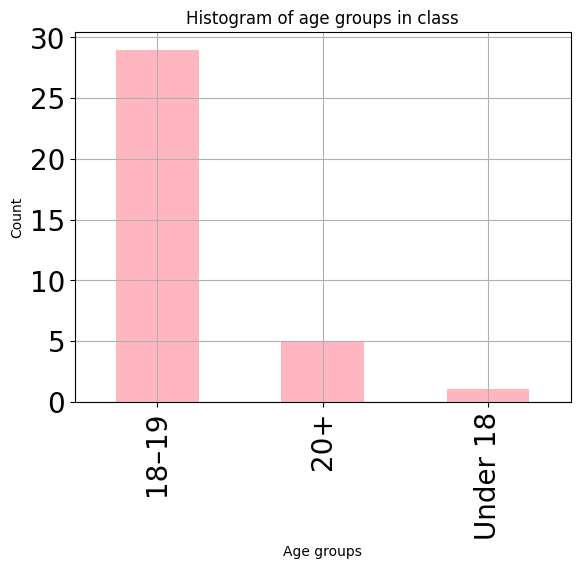

In [123]:
# The histogram shows that 18-19 age group has the highest number of students enrolled

age_group_count= survey_df["Age_group"].value_counts()
color= ("lightpink")
age_group_count.plot(kind="bar", color=color)
plt.xlabel("Age groups")
plt.ylabel("Count")
plt.title("Histogram of age groups in class")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid()



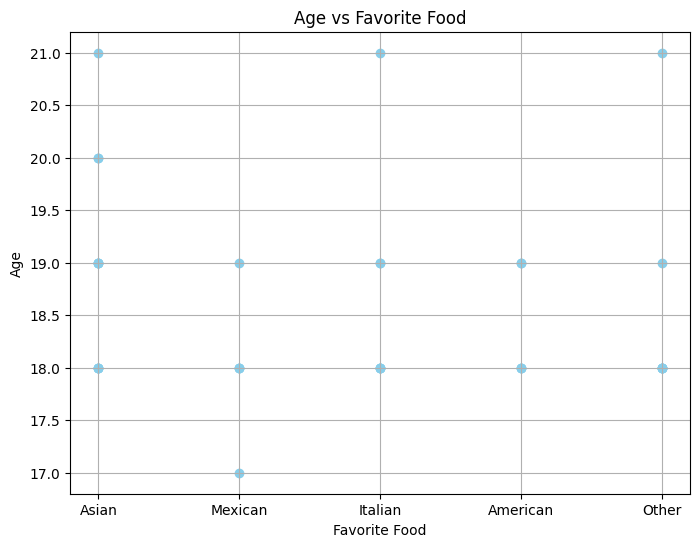

In [124]:
# This scatter plot shows relationship between number of age and favourite food. It seems like age does not have any effect on students' favourite food preferences. 
plt.figure(figsize=(8,6))
plt.scatter(survey_df["Food_clean"], survey_df["How old are you?"], color="skyblue")
plt.xlabel("Favorite Food")
plt.ylabel("Age")
plt.title("Age vs Favorite Food")
plt.grid(True)
plt.show()

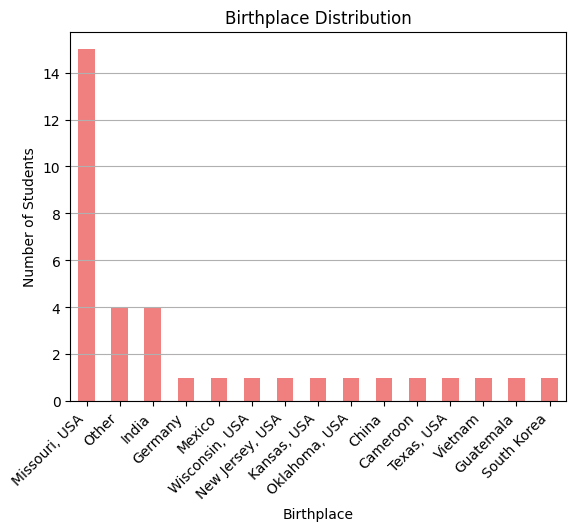

In [125]:
# Bar chart shows the number of students from each standardized birthplace. Most students in this class come from Missouri, USA.

def plot_birthplace_distribution(df, title="Birthplace Distribution"):
    counts = df["Birthplace_clean"].value_counts()
    
    counts.plot(kind="bar", color="lightcoral")
    plt.xlabel("Birthplace")
    plt.ylabel("Number of Students")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y")
    plt.show()
    

survey_df["Birthplace_clean"] = survey_df["What state/country were you born in?"].apply(clean_birthplace)
plot_birthplace_distribution(survey_df)



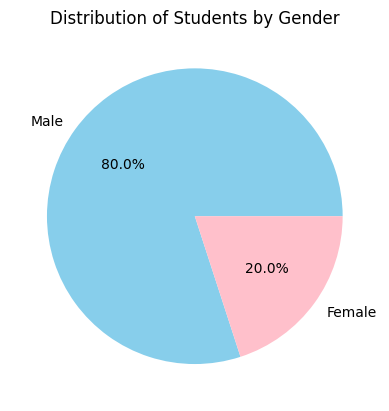

In [130]:
# Rename column once

def gender_new(pronoun):
    pronoun = str(pronoun).lower()
    
    if "he/him" in pronoun or "multiple: he/him and they/them" in pronoun:
        return "Male"
    elif "she/her" in pronoun:
        return "Female"
    else:
        return "Other"

survey_df["Gender_clean"] = survey_df["What are your pronouns?"].apply(gender_new)

pie_gender = survey_df["Gender_clean"].value_counts()

colors = ["skyblue", "pink"]

pie_gender.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=colors)

plt.ylabel("")
plt.title("Distribution of Students by Gender")
plt.show()


In [132]:
print(survey_df.columns)


Index(['Timestamp', 'Name', 'What are your pronouns?',
       'What state/country were you born in?',
       'How many siblings do you have?',
       'How much experience do you have programming?',
       'What class are you in? ', 'Are you working while in school?',
       'How many pets and of which kind do you have?',
       'What is your favorite type of food?', 'Where do you live?',
       'Do you take the metro?', 'What is your major?', 'How old are you?',
       'What is your favorite TV show?', 'What is your favorite video game?',
       'What is your favorite book?', 'Why are you taking this class? ',
       'Whats your favorite bash command?', 'Birthplace_raw',
       'Birthplace_clean', 'Pets_clean', 'Food_clean', 'Major_clean',
       'Age_group', 'Gender_clean'],
      dtype='object')
